# cGAN + MediaPipe — 128×128  (Model B — FULLY FIXED)

**Fixes applied vs original notebook:**
- Grayscale→RGB: CLAHE + skin-tone colorization (not flat grey copy)
- Padding added before MediaPipe (gives palm detector context)
- Multi-strategy detection cascade (4 attempts before giving up)
- Landmark regressor trained on real images → FROZEN
- Landmark loss IS inside GradientTape (real gradient, not just eval)
- Separate lambda schedules for pixel loss and landmark loss
- Detection diagnostic cell to measure rate before training

## Section 1 — Environment

In [ ]:
# ── Environment detection (Colab vs local Linux/WSL) ────────────────────────────
import os, sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def _find_repo_root(start):
    d = os.path.abspath(start)
    for _ in range(5):
        if os.path.isdir(os.path.join(d, 'data')) and os.path.isdir(os.path.join(d, 'notebooks')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    return os.path.abspath(start)

REPO_ROOT = None if IN_COLAB else _find_repo_root(os.getcwd())
print('Environment:', 'Google Colab' if IN_COLAB else f'Local ({sys.platform}) - repo root: {REPO_ROOT}')


In [ ]:
if IN_COLAB:
    !pip install tensorflow==2.19.0 mediapipe==0.10.14 opencv-python --quiet
    !pip install pytorch-fid scikit-image scikit-learn tqdm lpips --quiet
    !pip install torch torchvision --quiet
    print("All packages installed.")
else:
    print('Running locally -- make sure this environment has: tensorflow==2.19.0 (tensorflow[and-cuda] for GPU on Linux/WSL), mediapipe==0.10.14, opencv-python, pytorch-fid, scikit-image, scikit-learn, tqdm, lpips, torch, torchvision.')


In [ ]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Not running in Colab -- skipping Drive mount; using local paths.')


In [4]:
import os, json, csv, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from skimage.metrics import structural_similarity as ssim_fn

import cv2
import mediapipe as mp

warnings.filterwarnings('ignore', category=UserWarning)
print(f'TensorFlow : {tf.__version__}')
print(f'MediaPipe  : {mp.__version__}')
print(f'OpenCV     : {cv2.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
MediaPipe  : 0.10.14
OpenCV     : 4.13.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f'Global seed: {RANDOM_SEED}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f'GPU memory growth enabled: {gpus[0].name}')
    except RuntimeError as e:
        print(f'GPU config warning: {e}')

Global seed: 42
GPU memory growth enabled: /physical_device:GPU:0


In [ ]:
DRIVE_BASE     = '/content/drive/MyDrive/cgan_B_128mp' if IN_COLAB else os.path.join(REPO_ROOT, 'runs', 'cgan_B_128mp')
DATA_PATH      = '/content/ArASL_Database_54K_Final' if IN_COLAB else os.path.join(REPO_ROOT, 'data', 'ArASL_dataset')
LANDMARK_CACHE = os.path.join(DRIVE_BASE, 'landmarks_128px_v6_fixed.npy')

CHECKPOINT_DIR = os.path.join(DRIVE_BASE, 'checkpoints')
SAMPLES_DIR    = os.path.join(DRIVE_BASE, 'samples')
EVAL_DIR       = os.path.join(DRIVE_BASE, 'eval')
REAL_FID_DIR   = os.path.join(EVAL_DIR,   'fid_real')
HISTORY_DIR    = os.path.join(DRIVE_BASE, 'history')
PLOTS_DIR      = os.path.join(DRIVE_BASE, 'plots')
PROGRESS_FILE  = os.path.join(CHECKPOINT_DIR, 'progress.json')
REGRESSOR_PATH = os.path.join(CHECKPOINT_DIR, 'landmark_regressor.weights.h5')

for d in [CHECKPOINT_DIR, SAMPLES_DIR, EVAL_DIR, REAL_FID_DIR, HISTORY_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)
print("All directories ready.")


In [ ]:
# ── Dataset — auto-download from Hugging Face (no manual Drive upload needed) ──
# Source: pain/ArASL_Database_Grayscale on Hugging Face (54,049 imgs, 32 classes).
# Downloads straight to local Colab disk once per session — faster than reading
# from Drive and doesn't touch your Drive quota. Re-running is a no-op if present.
import pandas as pd

if not os.path.isdir(DATA_PATH) or not os.listdir(DATA_PATH):
    import io as _io, json as _json, urllib.request as _req
    try:
        import pyarrow.parquet as pq
    except ImportError:
        import subprocess; subprocess.run(["pip", "install", "-q", "pyarrow"]); import pyarrow.parquet as pq

    _parquet = "/content/arasl.parquet"
    if not os.path.exists(_parquet):
        print("Downloading ArASL dataset from Hugging Face (~30 MB)...")
        _req.urlretrieve(
            "https://huggingface.co/api/datasets/pain/ArASL_Database_Grayscale/parquet/default/train/0.parquet",
            _parquet)

    _names = ["ain","al","aleff","bb","dal","dha","dhad","fa","gaaf","ghain","ha","haa",
              "jeem","kaaf","khaa","la","laam","meem","nun","ra","saad","seen","sheen",
              "ta","taa","thaa","thal","toot","waw","ya","yaa","zay"]
    try:
        _md = pq.read_schema(_parquet).metadata or {}
        _hf = _md.get(b"huggingface")
        if _hf:
            _names = _json.loads(_hf)["info"]["features"]["label"]["names"]
    except Exception as e:
        print("metadata note:", e)

    os.makedirs(DATA_PATH, exist_ok=True)
    for n in _names:
        os.makedirs(os.path.join(DATA_PATH, n), exist_ok=True)

    _df = pd.read_parquet(_parquet)
    _counts = {}
    for v, lab in zip(_df["image"], _df["label"]):
        b = v["bytes"] if isinstance(v, dict) else v
        cls = _names[int(lab)] if int(lab) < len(_names) else f"class_{int(lab):02d}"
        k = _counts.get(cls, 0); _counts[cls] = k + 1
        Image.open(_io.BytesIO(b)).convert("L").save(os.path.join(DATA_PATH, cls, f"{cls}_{k:04d}.png"))
    print(f"Dataset ready: {sum(_counts.values())} images across {len(_counts)} classes -> {DATA_PATH}")
else:
    print(f"Dataset already present at {DATA_PATH} — skipping download.")


## Section 2 — Hyperparameters

In [7]:
# Architecture
Z_DIM        = 128
IMG_SIZE     = 128
IMG_CHANNELS = 1

# Training
EPOCHS         = 50
BATCH_SIZE     = 32
LR_G           = 2e-4
LR_D           = 1e-4
LR_DECAY_G     = 35
LR_DECAY_D     = 20
LABEL_SMOOTH   = 0.9

# Pixel structural loss schedule
LAMBDA_PIX_START = 0.5
LAMBDA_PIX_END   = 5.0
WARMUP_EP        = 10
PHASE2_EP        = 10

# Landmark loss schedule  [NEW]
# Phases in after pixel loss stabilises to avoid early destabilisation
LAMBDA_LM_START  = 0.0
LAMBDA_LM_END    = 2.0
WARMUP_LM_EP     = 15

# GAN balance
G_UPDATES_BASE = 2
G_D_RATIO_MAX  = 2.0

# Evaluation
N_FID_PER_CLASS  = 60
N_FID_SEEDS      = 5
N_PKLE_PER_CLASS = 15
SAVE_EVERY_N     = 5

# MediaPipe  [FIXED — detect on pseudo-color at 256px, NOT 128px grayscale]
MP_DETECT_SIZE      = 256
MP_DETECT_SIZE_FB   = 320
MP_CONFIDENCE       = 0.3
MP_CONFIDENCE_LOW   = 0.15
MP_MODEL_COMPLEX    = 1
MIN_VALID_DETECTIONS = 50

# Landmark regressor
REG_EPOCHS     = 20
REG_BATCH_SIZE = 64
REG_LR         = 1e-3

print('Model B cGAN + MediaPipe 128x128  [FIXED]')
print(f'  lambda_pixel   : {LAMBDA_PIX_START}->{LAMBDA_PIX_END} over ep1-{WARMUP_EP}')
print(f'  lambda_landmark: {LAMBDA_LM_START}->{LAMBDA_LM_END} from ep{WARMUP_LM_EP}')
print(f'  MP detect size : {MP_DETECT_SIZE}px pseudo-color (NOT grayscale)')

Model B cGAN + MediaPipe 128x128  [FIXED]
  lambda_pixel   : 0.5->5.0 over ep1-10
  lambda_landmark: 0.0->2.0 from ep15
  MP detect size : 256px pseudo-color (NOT grayscale)


## Section 3 — Data Loading

In [8]:
VALID_EXT = ('.png', '.jpg', '.jpeg')
images_list_pre, labels_list_pre = [], []
load_errors = 0

print(f'Loading from: {DATA_PATH}  (resizing to {IMG_SIZE}x{IMG_SIZE})')
for subfolder in tqdm(sorted(os.listdir(DATA_PATH)), desc='Classes'):
    spath = os.path.join(DATA_PATH, subfolder)
    if not os.path.isdir(spath): continue
    for fname in sorted(os.listdir(spath)):
        if not fname.lower().endswith(VALID_EXT): continue
        try:
            raw = tf.io.read_file(os.path.join(spath, fname))
            img = tf.image.decode_png(raw, channels=1)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
            img = tf.cast(img, tf.float32)
            img = (img - 127.5) / 127.5
            images_list_pre.append(img.numpy())
            labels_list_pre.append(subfolder)
        except Exception:
            load_errors += 1

print(f'Loaded : {len(images_list_pre)} images')
print(f'Errors : {load_errors}')

Loading from: /content/drive/MyDrive/ArASL_Database_54K_Final/ArASL_Database_54K_Final  (resizing to 128x128)


Classes: 100%|██████████| 32/32 [23:03<00:00, 43.25s/it]

Loaded : 54049 images
Errors : 0


In [9]:
images_array_pre = np.array(images_list_pre, dtype=np.float32)
labels_array_pre = np.array(labels_list_pre)

label_encoder  = LabelEncoder()
labels_int_pre = label_encoder.fit_transform(labels_array_pre)
num_classes    = len(label_encoder.classes_)
label_to_idx   = {l: i for i, l in enumerate(label_encoder.classes_)}
idx_to_label   = {i: l for l, i in label_to_idx.items()}

np.save(os.path.join(CHECKPOINT_DIR, 'classes.npy'), label_encoder.classes_)
print(f'Images shape : {images_array_pre.shape}')
print(f'Classes      : {num_classes}  --  {list(label_encoder.classes_)}')

Images shape : (54049, 128, 128, 1)
Classes      : 32  --  [np.str_('ain'), np.str_('al'), np.str_('aleff'), np.str_('bb'), np.str_('dal'), np.str_('dha'), np.str_('dhad'), np.str_('fa'), np.str_('gaaf'), np.str_('ghain'), np.str_('ha'), np.str_('haa'), np.str_('jeem'), np.str_('kaaf'), np.str_('khaa'), np.str_('la'), np.str_('laam'), np.str_('meem'), np.str_('nun'), np.str_('ra'), np.str_('saad'), np.str_('seen'), np.str_('sheen'), np.str_('ta'), np.str_('taa'), np.str_('thaa'), np.str_('thal'), np.str_('toot'), np.str_('waw'), np.str_('ya'), np.str_('yaa'), np.str_('zay')]


In [10]:
total  = len(images_array_pre)
counts = Counter(labels_array_pre)
print(f'Dataset: {total} images  .  {num_classes} classes')
for cls in sorted(counts):
    n = counts[cls]
    print(f'  {cls:10s}: {n:5d} ({n/total*100:.1f}%)')

Dataset: 54049 images  .  32 classes
  ain       :  2114 (3.9%)
  al        :  1343 (2.5%)
  aleff     :  1672 (3.1%)
  bb        :  1791 (3.3%)
  dal       :  1634 (3.0%)
  dha       :  1723 (3.2%)
  dhad      :  1670 (3.1%)
  fa        :  1955 (3.6%)
  gaaf      :  1705 (3.2%)
  ghain     :  1977 (3.7%)
  ha        :  1592 (2.9%)
  haa       :  1526 (2.8%)
  jeem      :  1552 (2.9%)
  kaaf      :  1774 (3.3%)
  khaa      :  1607 (3.0%)
  la        :  1746 (3.2%)
  laam      :  1832 (3.4%)
  meem      :  1765 (3.3%)
  nun       :  1819 (3.4%)
  ra        :  1659 (3.1%)
  saad      :  1895 (3.5%)
  seen      :  1638 (3.0%)
  sheen     :  1507 (2.8%)
  ta        :  1816 (3.4%)
  taa       :  1838 (3.4%)
  thaa      :  1766 (3.3%)
  thal      :  1582 (2.9%)
  toot      :  1791 (3.3%)
  waw       :  1371 (2.5%)
  ya        :  1722 (3.2%)
  yaa       :  1293 (2.4%)
  zay       :  1374 (2.5%)


## Section 4 — MediaPipe Extraction  [COMPLETELY REWRITTEN]

**Root cause fix:** Images are `Mode=L` (pure grayscale). Original `cv2.COLOR_GRAY2RGB` copies channel 3x = flat grey = palm detector fails.

**Changes:**
- `_gray_to_clahe_skintone()`: CLAHE sharpens edges + skin-tone colorization
- `_preprocess_for_mp()`: adds padding + upscales to 256px before detection
- `extract_landmarks()`: 4-strategy cascade
- Diagnostic cell to measure detection rate before building full cache

In [11]:
# ── Colorization helpers ─────────────────────────────────────────────────
# ROOT CAUSE: cv2.COLOR_GRAY2RGB copies 1 channel 3x = flat grey image
# MediaPipe palm detector was trained on real skin colors
# These functions synthesize plausible skin tones from grayscale intensity

def _gray_to_skintone(img_u8):
    """Map grayscale uint8 (H,W) to warm skin-tone RGB."""
    if img_u8.ndim == 3: img_u8 = img_u8[:, :, 0]
    f = img_u8.astype(np.float32) / 255.0
    r = np.clip(f * 210 + 40,  0, 255).astype(np.uint8)
    g = np.clip(f * 170 + 25,  0, 255).astype(np.uint8)
    b = np.clip(f * 140 + 10,  0, 255).astype(np.uint8)
    return np.stack([r, g, b], axis=-1)


def _gray_to_clahe_skintone(img_u8):
    """CLAHE contrast enhancement then skin-tone colorization.
    CLAHE sharpens local contrast (finger edges), skin-tone adds color cues.
    Best method for flat grey images with soft hand boundaries.
    """
    if img_u8.ndim == 3: img_u8 = img_u8[:, :, 0]
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(img_u8)
    if enhanced.mean() < 100:          # auto-invert dark-background images
        enhanced = cv2.bitwise_not(enhanced)
    return _gray_to_skintone(enhanced)


def _gray_to_clahe_only(img_u8):
    """CLAHE + plain RGB copy. Third fallback."""
    if img_u8.ndim == 3: img_u8 = img_u8[:, :, 0]
    clahe    = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(img_u8)
    return cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)


def _preprocess_for_mp(img_u8, target_size, colorize_fn, pad_ratio=0.15):
    """Add padding + upscale + colorize before running MediaPipe.
    Padding gives the palm detector background context missing in tight crops.
    """
    if img_u8.ndim == 3: img_u8 = img_u8[:, :, 0]
    pad_px   = int(max(img_u8.shape) * pad_ratio)
    bg       = int(img_u8.mean())
    padded   = cv2.copyMakeBorder(img_u8, pad_px, pad_px, pad_px, pad_px,
                                   cv2.BORDER_CONSTANT, value=bg)
    upscaled = cv2.resize(padded, (target_size, target_size),
                          interpolation=cv2.INTER_LANCZOS4)
    return colorize_fn(upscaled)

print("Colorization helpers defined.")

Colorization helpers defined.


In [12]:
# ── Core MediaPipe runner ────────────────────────────────────────────────
_mp_hands = mp.solutions.hands

def _run_mp(img_rgb, confidence):
    """Run MediaPipe Hands on pre-processed RGB. Returns float32 (63,) or None."""
    with _mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=confidence,
        model_complexity=MP_MODEL_COMPLEX
    ) as hands:
        res = hands.process(img_rgb)
        if res.multi_hand_landmarks:
            lm = res.multi_hand_landmarks[0].landmark
            return np.array([[p.x, p.y, p.z] for p in lm],
                            dtype=np.float32).flatten()
    return None


def _norm_to_u8(img_norm):
    """Convert [-1,1] (H,W,1) float32 to uint8 (H,W) grayscale."""
    return ((img_norm[:, :, 0] + 1.0) * 127.5).clip(0, 255).astype(np.uint8)

print("MediaPipe runner defined.")

MediaPipe runner defined.


In [13]:
# ── 4-strategy robust extractor ─────────────────────────────────────────
def extract_landmarks(img_norm):
    """FIXED replacement for original extract_landmarks().
    Strategy 1: CLAHE+Skin  256px  confidence=0.30  with padding
    Strategy 2: CLAHE+Skin  320px  confidence=0.30  with padding
    Strategy 3: CLAHE only  256px  confidence=0.15  with padding
    Strategy 4: Skin only   256px  confidence=0.15  NO padding
    Returns float32 (63,) or zeros on total failure.
    """
    img_u8 = _norm_to_u8(img_norm)

    rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE,    _gray_to_clahe_skintone)
    lm  = _run_mp(rgb, MP_CONFIDENCE)
    if lm is not None: return lm

    rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE_FB, _gray_to_clahe_skintone)
    lm  = _run_mp(rgb, MP_CONFIDENCE)
    if lm is not None: return lm

    rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE,    _gray_to_clahe_only)
    lm  = _run_mp(rgb, MP_CONFIDENCE_LOW)
    if lm is not None: return lm

    raw = cv2.resize(img_u8, (MP_DETECT_SIZE, MP_DETECT_SIZE),
                     interpolation=cv2.INTER_LANCZOS4)
    lm  = _run_mp(_gray_to_clahe_skintone(raw), MP_CONFIDENCE_LOW)
    if lm is not None: return lm

    return np.zeros(63, dtype=np.float32)


def extract_landmarks_eval(img_norm):
    """Evaluation variant: returns None on failure (skips pair in PKLE)."""
    lm = extract_landmarks(img_norm)
    return lm if lm.any() else None

print("Landmark extractors defined (4-strategy cascade).")

Landmark extractors defined (4-strategy cascade).


In [14]:
# ── DIAGNOSTIC — run before building cache ───────────────────────────────
def run_detection_diagnostic(images_pre, labels_pre, n_sample=300, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(images_pre), size=min(n_sample, len(images_pre)), replace=False)
    s1 = s2 = s3 = s4 = total = 0
    per_class = {}

    for i in tqdm(idx, desc='Diagnosing'):
        img_u8 = _norm_to_u8(images_pre[i])
        cls    = str(labels_pre[i])
        total += 1
        per_class.setdefault(cls, {'det': 0, 'total': 0})
        per_class[cls]['total'] += 1

        rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE,    _gray_to_clahe_skintone)
        if _run_mp(rgb, MP_CONFIDENCE) is not None:
            s1 += 1; per_class[cls]['det'] += 1; continue
        rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE_FB, _gray_to_clahe_skintone)
        if _run_mp(rgb, MP_CONFIDENCE) is not None:
            s2 += 1; per_class[cls]['det'] += 1; continue
        rgb = _preprocess_for_mp(img_u8, MP_DETECT_SIZE,    _gray_to_clahe_only)
        if _run_mp(rgb, MP_CONFIDENCE_LOW) is not None:
            s3 += 1; per_class[cls]['det'] += 1; continue
        raw = cv2.resize(img_u8, (MP_DETECT_SIZE, MP_DETECT_SIZE),
                         interpolation=cv2.INTER_LANCZOS4)
        if _run_mp(_gray_to_clahe_skintone(raw), MP_CONFIDENCE_LOW) is not None:
            s4 += 1; per_class[cls]['det'] += 1

    detected = s1 + s2 + s3 + s4
    print('=' * 55)
    print(f'Strategy 1 (CLAHE+Skin 256px @0.30+pad) : {s1:4d} ({s1/total*100:.1f}%)')
    print(f'Strategy 2 (CLAHE+Skin 320px @0.30+pad) : {s2:4d} ({s2/total*100:.1f}%)')
    print(f'Strategy 3 (CLAHE only 256px @0.15+pad) : {s3:4d} ({s3/total*100:.1f}%)')
    print(f'Strategy 4 (Skin only  256px @0.15 raw) : {s4:4d} ({s4/total*100:.1f}%)')
    print('-' * 55)
    print(f'Total detected : {detected}/{total} ({detected/total*100:.1f}%)')
    print('\nPer-class detection:')
    for cls in sorted(per_class):
        d = per_class[cls]['det']; t = per_class[cls]['total']
        pct = d / max(t, 1) * 100
        print(f'  {cls:12s} {d:4d}/{t:4d}  {pct:5.1f}%')
    if detected/total < 0.30:
        print('\nWARNING: <30% detection. Check image format.')
    elif detected/total < 0.60:
        print('\nWARNING: 30-60% detection. Acceptable but noisy.')
    else:
        print('\nOK: Good detection rate.')
    return detected / total

detection_rate = run_detection_diagnostic(images_array_pre, labels_array_pre, n_sample=300)

Diagnosing: 100%|██████████| 300/300 [00:47<00:00,  6.26it/s]

Strategy 1 (CLAHE+Skin 256px @0.30+pad) :   63 (21.0%)
Strategy 2 (CLAHE+Skin 320px @0.30+pad) :    4 (1.3%)
Strategy 3 (CLAHE only 256px @0.15+pad) :   19 (6.3%)
Strategy 4 (Skin only  256px @0.15 raw) :    3 (1.0%)
-------------------------------------------------------
Total detected : 89/300 (29.7%)

Per-class detection:
  ain             3/   8   37.5%
  al              0/   4    0.0%
  aleff           7/  15   46.7%
  bb              4/   9   44.4%
  dal             0/   8    0.0%
  dha             2/  13   15.4%
  dhad            1/   5   20.0%
  fa              2/   6   33.3%
  gaaf            6/  12   50.0%
  ghain           2/  10   20.0%
  ha              6/   9   66.7%
  haa             3/   7   42.9%
  jeem            3/   6   50.0%
  kaaf            7/  15   46.7%
  khaa            1/  19    5.3%
  la              3/  13   23.1%
  laam            0/   3    0.0%
  meem            3/  15   20.0%
  nun             2/   7   28.6%
  ra              4/   8   50.0%
  saad       

In [15]:
def load_or_compute_landmarks(images_pre, cache_path, expected_rows):
    if os.path.exists(cache_path):
        lm = np.load(cache_path)
        if lm.shape == (expected_rows, 63):
            n_det = int(lm.any(axis=1).sum())
            pct   = n_det / expected_rows * 100
            print(f'Cache loaded: {lm.shape}')
            print(f'  Detections: {n_det}/{expected_rows} ({pct:.1f}%)')
            if pct < 20.0:
                print(f'  WARNING: only {pct:.1f}% -- deleting stale cache...')
                os.remove(cache_path)
            else:
                return lm
        else:
            print(f'Shape mismatch {lm.shape}. Recomputing...')
            os.remove(cache_path)

    print(f'Computing landmarks (fixed pipeline) for {expected_rows:,} images...')
    lm_list = []
    for i in tqdm(range(expected_rows), desc='MediaPipe-fixed'):
        lm_list.append(extract_landmarks(images_pre[i]))
    lm = np.array(lm_list, dtype=np.float32)
    np.save(cache_path, lm)
    n_det = int(lm.any(axis=1).sum())
    print(f'Cache saved: {lm.shape}')
    print(f'Detections: {n_det}/{expected_rows} ({n_det/expected_rows*100:.1f}%)')
    return lm

real_landmarks_pre = load_or_compute_landmarks(
    images_array_pre, LANDMARK_CACHE, expected_rows=len(images_array_pre))

Cache loaded: (54049, 63)
  Detections: 14876/54049 (27.5%)


In [16]:
rng         = np.random.default_rng(RANDOM_SEED)
shuffle_idx = np.arange(len(images_array_pre))
rng.shuffle(shuffle_idx)

images_array   = images_array_pre[shuffle_idx]
labels_int     = labels_int_pre[shuffle_idx]
real_landmarks = real_landmarks_pre[shuffle_idx]

assert images_array.shape[0] == real_landmarks.shape[0]
assert images_array.shape[0] == labels_int.shape[0]
assert real_landmarks.shape[1] == 63
print(f'Shuffle done. images={images_array.shape}  landmarks={real_landmarks.shape}')

Shuffle done. images=(54049, 128, 128, 1)  landmarks=(54049, 63)


In [17]:
print('Building per-class prototypes...')
class_landmark_prototypes = np.zeros((num_classes, 63),                    dtype=np.float32)
class_image_prototypes    = np.zeros((num_classes, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
class_lm_valid_mask       = np.zeros(num_classes, dtype=bool)
detection_counts          = np.zeros(num_classes, dtype=int)
class_real_indices        = {}

for cls_idx in range(num_classes):
    cls_mask = labels_int == cls_idx
    idx_arr  = np.where(cls_mask)[0]
    class_real_indices[cls_idx] = idx_arr
    if len(idx_arr) > 0:
        class_image_prototypes[cls_idx] = images_array[idx_arr].mean(axis=0)
    cls_lm     = real_landmarks[cls_mask]
    valid_mask = cls_lm.any(axis=1)
    n_valid    = int(valid_mask.sum())
    detection_counts[cls_idx] = n_valid
    if n_valid >= MIN_VALID_DETECTIONS:
        class_landmark_prototypes[cls_idx] = cls_lm[valid_mask].mean(axis=0)
        class_lm_valid_mask[cls_idx]       = True

class_img_proto_tf = tf.constant(class_image_prototypes)
class_lm_valid_tf  = tf.constant(class_lm_valid_mask, dtype=tf.float32)
valid_cls = int(class_lm_valid_mask.sum())
print(f'Landmark prototypes: {valid_cls}/{num_classes} classes valid')
print(f'  Class        Valid LM   Total   Rate%   Gate')
for cls_idx in range(num_classes):
    n   = detection_counts[cls_idx]
    tot = int((labels_int == cls_idx).sum())
    ok  = 'OK' if class_lm_valid_mask[cls_idx] else 'FAIL'
    print(f'  {idx_to_label[cls_idx]:10s} {n:9d} {tot:7d} {n/max(tot,1)*100:7.1f}% {ok:>6s}')

Building per-class prototypes...
Landmark prototypes: 32/32 classes valid
  Class        Valid LM   Total   Rate%   Gate
  ain              436    2114    20.6%     OK
  al               185    1343    13.8%     OK
  aleff            751    1672    44.9%     OK
  bb               641    1791    35.8%     OK
  dal              207    1634    12.7%     OK
  dha              394    1723    22.9%     OK
  dhad             588    1670    35.2%     OK
  fa               786    1955    40.2%     OK
  gaaf             708    1705    41.5%     OK
  ghain            383    1977    19.4%     OK
  ha               591    1592    37.1%     OK
  haa              147    1526     9.6%     OK
  jeem             258    1552    16.6%     OK
  kaaf             827    1774    46.6%     OK
  khaa             189    1607    11.8%     OK
  la               232    1746    13.3%     OK
  laam             676    1832    36.9%     OK
  meem             527    1765    29.9%     OK
  nun              497    1819   

## Section 5 — Model Architecture  (identical to original)

In [18]:
class SelfAttention2D(tf.keras.layers.Layer):
    """SAGAN-style self-attention. gamma=0 init."""
    def __init__(self, channels, **kwargs):
        super().__init__(**kwargs)
        self.channels = channels
        ch8 = max(channels // 8, 1)
        self.q     = tf.keras.layers.Conv2D(ch8, 1, use_bias=False)
        self.k     = tf.keras.layers.Conv2D(ch8, 1, use_bias=False)
        self.v     = tf.keras.layers.Conv2D(channels, 1, use_bias=False)
        self.gamma = None

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma', shape=(), initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, x):
        B       = tf.shape(x)[0]
        H, W, C = x.shape[1], x.shape[2], x.shape[3]
        ch8     = max(C // 8, 1)
        q    = tf.reshape(self.q(x), [B, H * W, ch8])
        k    = tf.reshape(self.k(x), [B, H * W, ch8])
        v    = tf.reshape(self.v(x), [B, H * W, C])
        s    = tf.cast(ch8, tf.float32) ** -0.5
        attn = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) * s, axis=-1)
        out  = tf.reshape(tf.matmul(attn, v), [B, H, W, C])
        return x + self.gamma * out

    def get_config(self):
        cfg = super().get_config()
        cfg['channels'] = self.channels
        return cfg

In [19]:
def build_generator(z_dim, num_classes):
    noise_in = tf.keras.Input(shape=(z_dim,),       name='noise')
    label_in = tf.keras.Input(shape=(num_classes,), name='label')

    lbl = tf.keras.layers.Dense(128, use_bias=False)(label_in)
    lbl = tf.keras.layers.LeakyReLU(negative_slope=0.2)(lbl)

    x = tf.keras.layers.Concatenate()([noise_in, lbl])
    x = tf.keras.layers.Dense(4 * 4 * 512, use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Reshape((4, 4, 512))(x)

    x = tf.keras.layers.Conv2DTranspose(256, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(128, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(128, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)
    x = SelfAttention2D(128, name='self_attn')(x)

    x = tf.keras.layers.Conv2DTranspose(64, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(32, 4, 2, padding='same', use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x)

    out = tf.keras.layers.Conv2D(1, 3, padding='same', activation='tanh')(x)
    return tf.keras.Model([noise_in, label_in], out, name='Generator_B_128mp')

In [20]:
def build_discriminator(num_classes):
    SN = tf.keras.layers.SpectralNormalization

    image_in = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name='image')
    label_in = tf.keras.Input(shape=(num_classes,),           name='label')

    lp = layers.Dense(IMG_SIZE * IMG_SIZE)(label_in)
    lp = layers.Reshape((IMG_SIZE, IMG_SIZE, 1))(lp)
    x  = layers.Concatenate()([image_in, lp])

    x = SN(layers.Conv2D(64,  (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    x = SN(layers.Conv2D(128, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x); x = layers.Dropout(0.2)(x)

    x = SN(layers.Conv2D(256, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x); x = layers.Dropout(0.2)(x)

    x = SN(layers.Conv2D(512, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x); x = layers.Dropout(0.3)(x)

    x = SN(layers.Conv2D(512, (4,4), strides=2, padding='same'))(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x); x = layers.Dropout(0.3)(x)

    x   = layers.Flatten()(x)
    out = layers.Dense(1)(x)
    return tf.keras.Model([image_in, label_in], out, name='Discriminator_B_128mp')

In [21]:
generator     = build_generator(Z_DIM, num_classes)
discriminator = build_discriminator(num_classes)
generator.summary(); print()
discriminator.summary()
print(f'Generator     : {generator.count_params():,} params')
print(f'Discriminator : {discriminator.count_params():,} params')

Model: "Generator_B_128mp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      4,096 │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 128)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8192)      │  2,097,152 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8192)      │     32,768 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 8192)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  2,097,152 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    524,288 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    262,144 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attn           │ (None, 32, 32,    │     20,481 │ re_lu_3[0][0]     │
│ (SelfAttention2D)   │ 128)              │            │                 

 Total params: 5,204,642 (19.85 MB)

 Trainable params: 5,187,042 (19.79 MB)

 Non-trainable params: 17,600 (68.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16384)     │    540,672 │ label[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 128,  │          0 │ dense_2[0][0]     │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ image[0][0],      │
│ (Concatenate)       │ 2)                │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 64, 64,    │      2,176 │ concatenate_1[0]… │
│ (SpectralNormaliza… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 64, 64,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 32, 32,    │    131,328 │ leaky_re_lu_1[0]… │
│ (SpectralNormaliza… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 32, 32,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32, 32,    │          0 │ leaky_re_lu_2[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 16, 16,    │    524,800 │ dropout[0][0]     │
│ (SpectralNormaliza… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 16, 16,    │          0 │ spectral_normali… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_3[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 8, 8, 512) │  2,098,176 │ dropout_1[0][0]   │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 8, 8, 512) │          0 │ spectral_normali… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 8, 8, 512) │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_normaliza… │ (None, 4, 4, 512) │  4,195,328 │ dropout_2[0][0]   │
│ (SpectralNormaliza… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 4, 4, 512) │          0 │ spectral_normali

 Total params: 7,500,673 (28.61 MB)

 Trainable params: 7,499,201 (28.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

Generator     : 5,204,642 params
Discriminator : 7,500,673 params


## Section 5b — Landmark Regressor  [NEW]

A lightweight CNN trained on real images to predict 63 landmark coordinates.
Trained once, then **frozen**. Used inside `GradientTape` as a differentiable
proxy for MediaPipe — so landmark geometry actually guides the generator gradient.

In [22]:
def build_landmark_regressor(img_size=128):
    """Lightweight CNN: image (H,W,1) -> 63 normalised landmark coordinates.
    Trained on real images with MediaPipe labels, then FROZEN.
    """
    inp = tf.keras.Input(shape=(img_size, img_size, 1), name='image')

    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding='same')(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # sigmoid: output in [0,1] -- landmark coords are normalised to image size
    out = tf.keras.layers.Dense(63, activation='sigmoid', name='landmarks')(x)
    return tf.keras.Model(inp, out, name='LandmarkRegressor')

In [24]:
def train_landmark_regressor(regressor, images_array, real_landmarks,
                               save_path=None, epochs=REG_EPOCHS,
                               batch_size=REG_BATCH_SIZE, lr=REG_LR):
    """Train on real images where MediaPipe succeeded (non-zero landmarks).
    Saves weights if save_path provided. Returns trained frozen regressor.
    """
    if save_path and os.path.exists(save_path):
        regressor.build((None, IMG_SIZE, IMG_SIZE, 1))
        regressor.load_weights(save_path)
        regressor.trainable = False
        print(f'Regressor loaded from {save_path} (frozen)')
        return regressor

    valid_mask  = real_landmarks.any(axis=1)
    valid_imgs  = images_array[valid_mask]
    valid_lm    = np.clip(real_landmarks[valid_mask], 0.0, 1.0)
    print(f'Training regressor on {len(valid_imgs)} images ({valid_mask.mean()*100:.1f}% of dataset)')

    if len(valid_imgs) < 100:
        print('WARNING: Very few valid landmarks. Regressor quality will be low.')

    regressor.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])

    history = regressor.fit(
        valid_imgs, valid_lm,
        epochs=epochs, batch_size=batch_size, validation_split=0.1,
        callbacks=[
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3,
                                                  factor=0.5, verbose=1),
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                              restore_best_weights=True, verbose=1)
        ], verbose=1
    )

    if save_path:
        regressor.save_weights(save_path)
        print(f'Regressor weights saved: {save_path}')

    regressor.trainable = False
    print(f'Regressor FROZEN. Final val_loss={min(history.history["val_loss"]):.5f}')
    return regressor


landmark_regressor = build_landmark_regressor(img_size=IMG_SIZE)
landmark_regressor = train_landmark_regressor(
    landmark_regressor, images_array, real_landmarks, save_path=REGRESSOR_PATH)
print(f'Regressor params: {landmark_regressor.count_params():,}')

Training regressor on 14876 images (27.5% of dataset)
Epoch 1/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 0.0119 - mae: 0.0793 - val_loss: 0.0138 - val_mae: 0.0868 - learning_rate: 0.0010
Epoch 2/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0067 - mae: 0.0569 - val_loss: 0.0097 - val_mae: 0.0662 - learning_rate: 0.0010
Epoch 3/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0058 - mae: 0.0499 - val_loss: 0.0124 - val_mae: 0.0708 - learning_rate: 0.0010
Epoch 4/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0051 - mae: 0.0455 - val_loss: 0.0186 - val_mae: 0.0847 - learning_rate: 0.0010
Epoch 5/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0046 - mae: 0.0426 - val_loss: 0.0081 - val_mae: 0.0564 - learning_rate: 0.0010
Epoch 6/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0043 - mae: 0.0406 - val_loss: 0.0135 - val_mae: 0.0739 - learning_rate: 0.0010
Epoch 7/20
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - mae: 0.0392 - val_loss:

## Section 6 — Loss Schedules  [UPDATED]

Two separate lambda schedules:
- `lambda_pixel`: same warm-up as original (0.5→5.0 over ep1-10)
- `lambda_landmark`: phases in at ep15 (0→2.0) after pixel loss is stable

In [25]:
def get_lambda_pixel(epoch):
    """Pixel structural loss weight — same warm-up as original."""
    if epoch >= WARMUP_EP:
        return float(LAMBDA_PIX_END)
    t = epoch / max(WARMUP_EP, 1)
    return float(LAMBDA_PIX_START + t * (LAMBDA_PIX_END - LAMBDA_PIX_START))


def get_lambda_landmark(epoch):
    """Landmark loss weight — phases in after pixel loss is stable.
    Zero for first WARMUP_LM_EP epochs, then ramps to LAMBDA_LM_END.
    """
    if epoch < WARMUP_LM_EP:
        return 0.0
    t = (epoch - WARMUP_LM_EP) / max(WARMUP_EP, 1)
    return float(min(LAMBDA_LM_START + t * (LAMBDA_LM_END - LAMBDA_LM_START),
                     LAMBDA_LM_END))


print(f'  {"Epoch":>6s} {"lambda_pixel":>14s} {"lambda_landmark":>16s}')
print('  ' + '-' * 38)
for ep in [0, 5, 10, 15, 20, 30, 50]:
    print(f'  {ep:6d} {get_lambda_pixel(ep):14.2f} {get_lambda_landmark(ep):16.2f}')

   Epoch   lambda_pixel  lambda_landmark
  --------------------------------------
       0           0.50             0.00
       5           2.75             0.00
      10           5.00             0.00
      15           5.00             0.00
      20           5.00             1.00
      30           5.00             2.00
      50           5.00             2.00


## Section 7 — Visualisation Utilities

In [26]:
TEST_LABELS = [l for l in ['bb','ain','gaaf','al','ha'] if l in label_to_idx]
tf.random.set_seed(RANDOM_SEED)
EVAL_NOISE  = tf.random.normal([len(TEST_LABELS), Z_DIM], seed=RANDOM_SEED)
print(f'Test labels : {TEST_LABELS}')

Test labels : ['bb', 'ain', 'gaaf', 'al', 'ha']


In [27]:
def generate_and_save_images(model, epoch, save_dir=None):
    if save_dir is None: save_dir = SAMPLES_DIR
    n   = len(TEST_LABELS)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for i, lbl in enumerate(TEST_LABELS):
        loh   = tf.one_hot([label_to_idx[lbl]], depth=num_classes)
        noise = EVAL_NOISE[i:i+1]
        gen   = model([noise, loh], training=False)
        img   = (gen[0,:,:,0].numpy() * 127.5 + 127.5).clip(0, 255).astype('uint8')
        axes[i].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[i].set_title(lbl, fontsize=13, fontweight='bold')
        axes[i].axis('off')
    plt.suptitle(f'cGAN-B 128px+MediaPipe [FIXED] -- Epoch {epoch}', fontsize=14, y=1.02)
    plt.tight_layout()
    p = os.path.join(save_dir, f'epoch_{epoch:04d}.png')
    plt.savefig(p, dpi=300, bbox_inches='tight')
    plt.show(); plt.close()
    return p

## Section 8 — Training Loop  [FULLY REWRITTEN]

**Key change:** `landmark_regressor(fake)` is now **inside** `tf.GradientTape`.

```
G_total = G_adversarial
        + lambda_pixel(epoch)    * G_pixel_structural   [L1 vs real/prototype]
        + lambda_landmark(epoch) * G_landmark           [regressor MSE -- real gradient!]
        + diversity_penalty
```

The frozen regressor evaluates the fake image and compares to real landmark targets.
MSE flows back through the generator weights. This is the fix for the original design flaw.

In [28]:
def train_B(generator, discriminator, landmark_regressor,
             images, labels, real_landmarks,
             class_img_proto_tf, class_real_indices,
             z_dim, num_classes, epochs, batch_size):

    g_opt = tf.keras.optimizers.Adam(LR_G, beta_1=0.5, beta_2=0.999, clipnorm=1.0)
    d_opt = tf.keras.optimizers.Adam(LR_D, beta_1=0.5, beta_2=0.999, clipnorm=1.0)
    bce   = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    ckpt     = tf.train.Checkpoint(generator=generator, discriminator=discriminator,
                                    g_opt=g_opt, d_opt=d_opt)
    ckpt_mgr = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=5)

    start_ep = 0
    hist = {k: [] for k in ['d','g_adv','g_pix','g_lm','g_total','gd_ratio',
                              'lam_pix','lam_lm']}
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE) as f:
            prog = json.load(f)
        start_ep = prog.get('last_epoch', 0)
        for k in hist: hist[k] = prog.get(k, [])
        if ckpt_mgr.latest_checkpoint:
            ckpt.restore(ckpt_mgr.latest_checkpoint)
            print(f'Resumed from epoch {start_ep}')

    N   = len(images)
    sp  = N // batch_size
    g_n = G_UPDATES_BASE

    @tf.function
    def train_step_d(real_imgs, real_lbs):
        noise = tf.random.normal([tf.shape(real_imgs)[0], z_dim])
        with tf.GradientTape() as t:
            fake  = generator([noise, real_lbs], training=True)
            r_out = discriminator([real_imgs, real_lbs], training=True)
            f_out = discriminator([fake,      real_lbs], training=True)
            d_loss = (bce(tf.ones_like(r_out) * LABEL_SMOOTH, r_out) +
                      bce(tf.zeros_like(f_out), f_out))
        d_opt.apply_gradients(
            zip(t.gradient(d_loss, discriminator.trainable_variables),
                discriminator.trainable_variables))
        return d_loss

    @tf.function
    def train_step_g(real_imgs, real_lbs, struct_targets,
                      batch_lm_targets, lam_pix_tf, lam_lm_tf):
        """Generator step with real landmark loss inside GradientTape.
        batch_lm_targets: (B,63) real landmark coords -- zeros = failed detection
        """
        LAMBDA_DIV = 0.05
        noise = tf.random.normal([tf.shape(real_imgs)[0], z_dim])

        with tf.GradientTape() as t:
            fake  = generator([noise, real_lbs], training=True)
            f_out = discriminator([fake, real_lbs], training=True)

            # (1) Adversarial
            g_adv = bce(tf.ones_like(f_out), f_out)

            # (2) Pixel structural (L1)
            g_pix = tf.reduce_mean(tf.abs(fake - struct_targets))

            # (3) LANDMARK LOSS [THE FIX] ─────────────────────────────────
            # Frozen regressor: differentiable w.r.t. generator weights
            pred_lm = landmark_regressor(fake, training=False)   # (B, 63)
            # Mask out samples where MediaPipe failed (zeros in real_lm)
            lm_valid = tf.cast(
                tf.reduce_any(batch_lm_targets != 0.0, axis=1, keepdims=True),
                tf.float32)                                        # (B, 1)
            g_lm = tf.reduce_mean(
                tf.square(pred_lm - batch_lm_targets) * lm_valid)
            # ─────────────────────────────────────────────────────────────

            # (4) Diversity penalty
            flat    = tf.reshape(fake, [tf.shape(fake)[0], -1])
            div_pen = -LAMBDA_DIV * tf.reduce_mean(
                          tf.math.reduce_variance(flat, axis=1))

            g_loss = g_adv + lam_pix_tf * g_pix + lam_lm_tf * g_lm + div_pen

        g_opt.apply_gradients(
            zip(t.gradient(g_loss, generator.trainable_variables),
                generator.trainable_variables))
        return g_adv, g_pix, g_lm

    # ── Main training loop ───────────────────────────────────────────────
    for epoch in range(start_ep, epochs):

        if epoch == LR_DECAY_D:
            d_opt.learning_rate.assign(LR_D / 2)
            print(f'  [ep{epoch+1}] D LR -> {LR_D/2:.0e}')
        if epoch == LR_DECAY_G:
            g_opt.learning_rate.assign(LR_G / 2)
            print(f'  [ep{epoch+1}] G LR -> {LR_G/2:.0e}')

        lam_pix    = get_lambda_pixel(epoch)
        lam_lm     = get_lambda_landmark(epoch)
        lam_pix_tf = tf.constant(lam_pix, dtype=tf.float32)
        lam_lm_tf  = tf.constant(lam_lm,  dtype=tf.float32)

        rng    = np.random.default_rng(RANDOM_SEED + epoch)
        idx    = np.arange(N); rng.shuffle(idx)
        imgs_e = images[idx]; lbs_e = labels[idx]; lms_e = real_landmarks[idx]

        ep_d, ep_ga, ep_gp, ep_glm = [], [], [], []

        for step in range(sp):
            s, e     = step * batch_size, (step + 1) * batch_size
            r_imgs   = tf.constant(imgs_e[s:e], dtype=tf.float32)
            r_lbs    = tf.one_hot(lbs_e[s:e], depth=num_classes)
            li_np    = lbs_e[s:e]
            batch_lm = tf.constant(lms_e[s:e], dtype=tf.float32)

            d_l = train_step_d(r_imgs, r_lbs)
            ep_d.append(float(d_l))

            if epoch < PHASE2_EP:
                struct_tgt = tf.gather(class_img_proto_tf, tf.constant(li_np))
            else:
                tgt_list   = [images[np.random.choice(class_real_indices[int(ci)])]
                               for ci in li_np]
                struct_tgt = tf.constant(np.stack(tgt_list), dtype=tf.float32)

            ga_acc = gp_acc = glm_acc = 0.0
            for _ in range(g_n):
                ga, gp, glm = train_step_g(
                    r_imgs, r_lbs, struct_tgt, batch_lm, lam_pix_tf, lam_lm_tf)
                ga_acc += float(ga); gp_acc += float(gp); glm_acc += float(glm)
            ep_ga.append(ga_acc / g_n)
            ep_gp.append(gp_acc / g_n)
            ep_glm.append(glm_acc / g_n)

            if step % 200 == 0:
                print(f'  ep{epoch+1:3d} st{step:4d} '
                      f'D={np.mean(ep_d):.4f} '
                      f'Ga={np.mean(ep_ga):.4f} '
                      f'Gpix={np.mean(ep_gp):.4f} '
                      f'Glm={np.mean(ep_glm):.4f} '
                      f'lp={lam_pix:.2f} ll={lam_lm:.2f}')

        ep_d_m   = float(np.mean(ep_d))
        ep_ga_m  = float(np.mean(ep_ga))
        ep_gp_m  = float(np.mean(ep_gp))
        ep_glm_m = float(np.mean(ep_glm))
        ep_gt_m  = ep_ga_m + lam_pix * ep_gp_m + lam_lm * ep_glm_m
        gd_r     = ep_gt_m / max(ep_d_m, 0.01)
        phase    = 'P1' if epoch < PHASE2_EP else 'P2'
        lm_phase = 'LM-off' if lam_lm == 0 else f'LM-on(l={lam_lm:.2f})'

        hist['d'].append(ep_d_m);      hist['g_adv'].append(ep_ga_m)
        hist['g_pix'].append(ep_gp_m); hist['g_lm'].append(ep_glm_m)
        hist['g_total'].append(ep_gt_m); hist['gd_ratio'].append(gd_r)
        hist['lam_pix'].append(lam_pix); hist['lam_lm'].append(lam_lm)

        print(f'Ep{epoch+1}/{epochs} [{phase}][{lm_phase}]: '
              f'D={ep_d_m:.4f} Ga={ep_ga_m:.4f} '
              f'Gpix={ep_gp_m:.4f} Glm={ep_glm_m:.4f} '
              f'Gt={ep_gt_m:.4f} G/D={gd_r:.2f}x')

        if   gd_r > G_D_RATIO_MAX * 1.5: g_n = min(G_UPDATES_BASE + 2, 5)
        elif gd_r > G_D_RATIO_MAX:        g_n = G_UPDATES_BASE + 1
        else:                              g_n = G_UPDATES_BASE

        if (epoch + 1) % SAVE_EVERY_N == 0 or epoch == 0:
            generate_and_save_images(generator, epoch + 1)

        ckpt_mgr.save()
        with open(PROGRESS_FILE, 'w') as f:
            json.dump({'last_epoch': epoch + 1, **hist}, f)
        generator.save_weights(os.path.join(CHECKPOINT_DIR, 'generator.weights.h5'))
        discriminator.save_weights(os.path.join(CHECKPOINT_DIR, 'discriminator.weights.h5'))

    print('Training complete.')
    return hist

In [29]:
print('Starting Model B -- cGAN + MediaPipe 128x128 [FIXED]')
print(f'  LR_G={LR_G}  LR_D={LR_D}')
print(f'  lambda_pixel  : {LAMBDA_PIX_START}->{LAMBDA_PIX_END} over ep1-{WARMUP_EP}')
print(f'  lambda_lm     : 0->{LAMBDA_LM_END} from ep{WARMUP_LM_EP}')
print()

hist = train_B(
    generator=generator,
    discriminator=discriminator,
    landmark_regressor=landmark_regressor,
    images=images_array,
    labels=labels_int,
    real_landmarks=real_landmarks,
    class_img_proto_tf=class_img_proto_tf,
    class_real_indices=class_real_indices,
    z_dim=Z_DIM,
    num_classes=num_classes,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Starting Model B -- cGAN + MediaPipe 128x128 [FIXED]
  LR_G=0.0002  LR_D=0.0001
  lambda_pixel  : 0.5->5.0 over ep1-10
  lambda_lm     : 0->2.0 from ep15



Resumed from epoch 50
Training complete.


## Section 9 — Loss Curves  [UPDATED — 6 panels]

ValueError: x and y must have same first dimension, but have shapes (50,) and (0,)

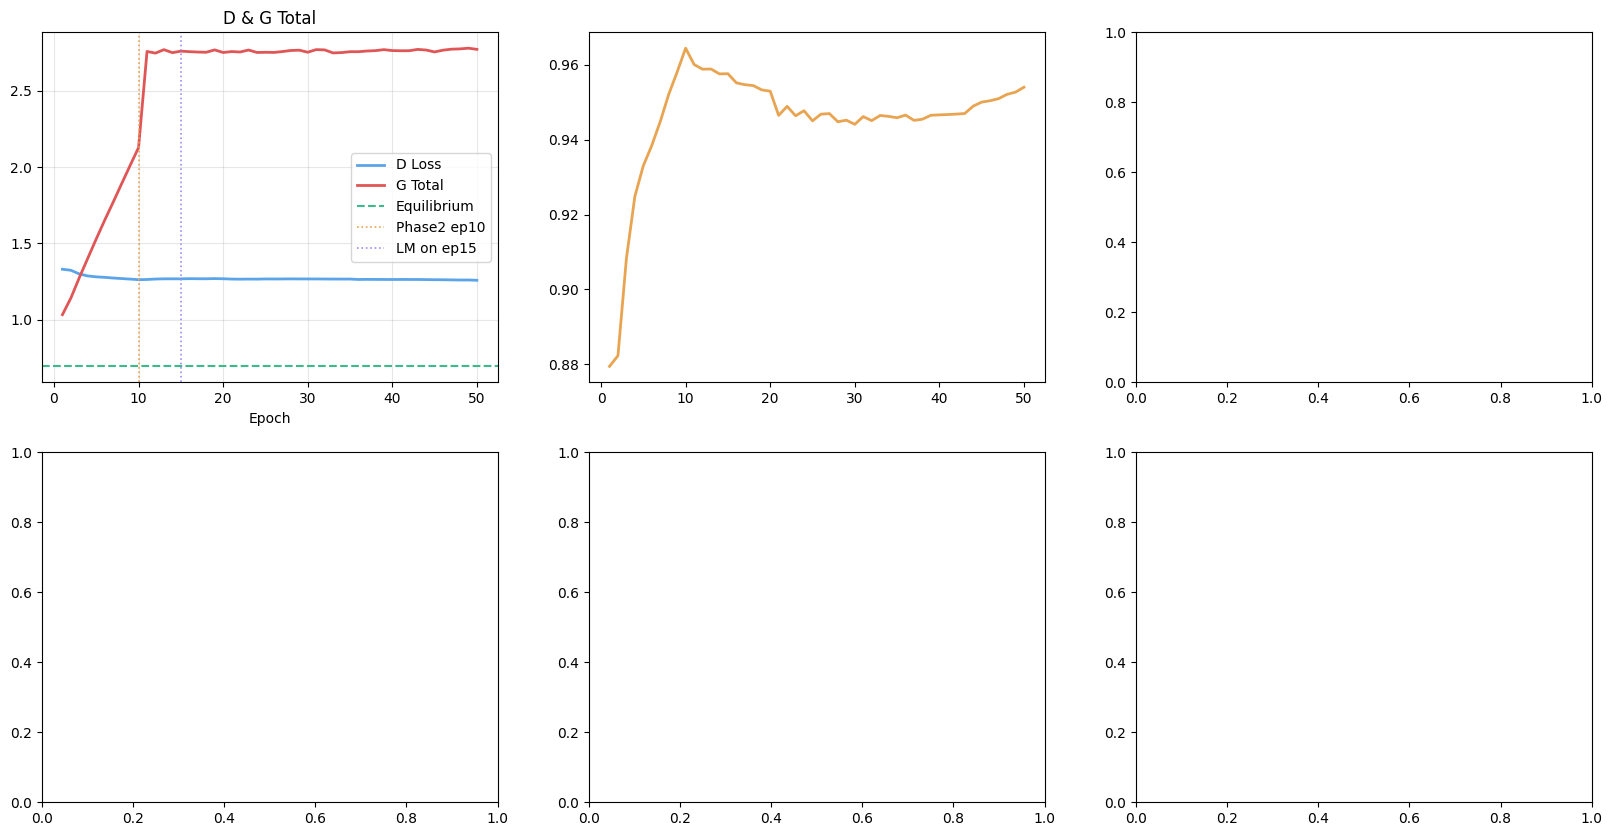

In [30]:
def plot_losses(hist, save_dir=PLOTS_DIR):
    if not hist.get('d'): print('No history.'); return
    ep  = list(range(1, len(hist['d']) + 1))
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    axes[0,0].plot(ep, hist['d'],       '#5ba4e8', lw=2, label='D Loss')
    axes[0,0].plot(ep, hist['g_total'], '#e05555', lw=2, label='G Total')
    axes[0,0].axhline(0.693, color='#3dba8c', ls='--', lw=1.5, label='Equilibrium')
    axes[0,0].axvline(PHASE2_EP,    color='#e8a450', ls=':', lw=1.2, label=f'Phase2 ep{PHASE2_EP}')
    axes[0,0].axvline(WARMUP_LM_EP, color='#9d8df5', ls=':', lw=1.2, label=f'LM on ep{WARMUP_LM_EP}')
    axes[0,0].set(title='D & G Total', xlabel='Epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(ep, hist['g_adv'], '#e8a450', lw=2, label='G Adversarial')
    axes[0,1].plot(ep, hist['g_pix'], '#9d8df5', lw=2, label='G Pixel Structural')
    axes[0,1].plot(ep, hist['g_lm'],  '#3dba8c', lw=2, label='G Landmark (Regressor)')
    axes[0,1].set(title='Generator Loss Components', xlabel='Epoch')
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    axes[0,2].plot(ep, hist['lam_pix'], '#5ba4e8', lw=2, label='lambda pixel')
    axes[0,2].plot(ep, hist['lam_lm'],  '#3dba8c', lw=2, label='lambda landmark')
    axes[0,2].set(title='Loss Weights (lambda)', xlabel='Epoch')
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

    axes[1,0].plot(ep, hist['gd_ratio'], '#58de99', lw=2)
    axes[1,0].axhline(1.0,          color='#3dba8c', ls='--', lw=1.5, label='Balance')
    axes[1,0].axhline(G_D_RATIO_MAX, color='#e8a450', ls='--', lw=1.2, label='Threshold')
    axes[1,0].set(title='G/D Ratio', xlabel='Epoch'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    axes[1,1].plot(ep, hist['g_lm'], '#3dba8c', lw=2)
    axes[1,1].axvline(WARMUP_LM_EP, color='#9d8df5', ls=':', lw=1.5,
                       label=f'LM activated ep{WARMUP_LM_EP}')
    axes[1,1].set(title='Landmark Loss (should decrease after activation)', xlabel='Epoch')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    axes[1,2].plot(ep, hist['g_pix'], '#9d8df5', lw=2)
    axes[1,2].set(title='Pixel Structural Loss', xlabel='Epoch'); axes[1,2].grid(alpha=0.3)

    plt.suptitle('Model B -- cGAN + MediaPipe 128x128  [FIXED]', fontsize=14)
    plt.tight_layout()
    p = os.path.join(save_dir, 'B_loss_curves_fixed.png')
    plt.savefig(p, dpi=300, bbox_inches='tight'); plt.show(); plt.close()
    print(f'Saved: {p}')

plot_losses(hist)

## Section 10 — Evaluation Suite  (FID + SSIM + LPIPS + PKLE + Diversity)

In [31]:
try:
    from pytorch_fid import fid_score
    import torch
except ImportError:
    import subprocess; subprocess.run(['pip','install','pytorch-fid','--quiet'])
    from pytorch_fid import fid_score; import torch
FID_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [32]:
def save_balanced_real(imgs, lbls, out_dir, n_per_class=N_FID_PER_CLASS):
    os.makedirs(out_dir, exist_ok=True); cnt = 0
    for ci in range(num_classes):
        for i in np.where(lbls == ci)[0][:n_per_class]:
            img = (imgs[i,:,:,0]*127.5+127.5).clip(0,255).astype(np.uint8)
            Image.fromarray(np.stack([img,img,img],-1)).save(
                os.path.join(out_dir, f'r_{cnt:05d}.png')); cnt += 1
    print(f'Saved {cnt} balanced real images')


def compute_fid(gen, num_cls, z_dim, real_dir, eval_dir,
                 n_runs=N_FID_SEEDS, n_per=N_FID_PER_CLASS):
    scores = []
    for seed in range(n_runs):
        gdir = os.path.join(eval_dir, f'fid_fake_s{seed:02d}')
        os.makedirs(gdir, exist_ok=True)
        tf.random.set_seed(seed); cnt = 0
        for ci in range(num_cls):
            loh   = tf.one_hot([ci]*n_per, depth=num_cls)
            noise = tf.random.normal([n_per, z_dim], seed=seed*100+ci)
            fakes = gen([noise, loh], training=False).numpy()
            for j in range(n_per):
                img = (fakes[j,:,:,0]*127.5+127.5).clip(0,255).astype(np.uint8)
                Image.fromarray(np.stack([img,img,img],-1)).save(
                    os.path.join(gdir, f'f_{cnt:05d}.png')); cnt += 1
        fv = fid_score.calculate_fid_given_paths(
            [real_dir, gdir], batch_size=32, device=FID_DEVICE, dims=2048)
        scores.append(fv); print(f'  Seed {seed}: FID={fv:.4f}')
    m, s  = float(np.mean(scores)), float(np.std(scores))
    ci95  = 1.96*s/np.sqrt(n_runs)
    print(f'FID: {m:.4f} +/- {s:.4f}  95%CI=[{m-ci95:.4f},{m+ci95:.4f}]')
    return m, s, scores

save_balanced_real(images_array, labels_int, REAL_FID_DIR)
fid_m, fid_s, fid_scores = compute_fid(generator, num_classes, Z_DIM, REAL_FID_DIR, EVAL_DIR)

Saved 1920 balanced real images
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 668MB/s]
100%|██████████| 60/60 [00:17<00:00,  3.45it/s]


  Seed 0: FID=214.4525


100%|██████████| 60/60 [00:17<00:00,  3.40it/s]


  Seed 1: FID=213.5229


...

  Seed 2: FID=214.8800


100%|██████████| 60/60 [00:15<00:00,  3.81it/s]


  Seed 3: FID=214.4939


100%|██████████| 60/60 [00:18<00:00,  3.25it/s]


  Seed 4: FID=214.5733
FID: 214.3845 +/- 0.4561  95%CI=[213.9848,214.7843]


In [33]:
def compute_ssim(gen, n_per=N_PKLE_PER_CLASS, seed=RANDOM_SEED):
    tf.random.set_seed(seed); np.random.seed(seed)
    all_s, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        ridx  = np.where(labels_int==ci)[0][:n_per]
        if not len(ridx): continue
        loh   = tf.one_hot([ci]*len(ridx), depth=num_classes)
        noise = tf.random.normal([len(ridx), Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy()
        cls_s = []
        for i in range(len(ridx)):
            r = (images_array[ridx[i],:,:,0]+1)/2
            f = (fakes[i,:,:,0]+1)/2
            cls_s.append(float(ssim_fn(r, f, data_range=1.0))); all_s.append(cls_s[-1])
        per[cname] = float(np.mean(cls_s))
    m = float(np.nanmean(all_s)); s = float(np.nanstd(all_s))
    print(f'SSIM: {m:.4f} +/- {s:.4f}')
    return m, s, per

ssim_m, ssim_s, ssim_per = compute_ssim(generator)

SSIM: 0.5568 +/- 0.1721


In [34]:
LPIPS_OK = False
try:
    import lpips as lpips_lib
    lpips_fn = lpips_lib.LPIPS(net='vgg'); LPIPS_OK = True
    print('LPIPS available (VGG)')
except ImportError:
    print('pip install lpips first')

def compute_lpips(gen, n_per=10, seed=RANDOM_SEED):
    if not LPIPS_OK: return float('nan'), float('nan'), {}
    import torch
    tf.random.set_seed(seed); np.random.seed(seed)
    all_l, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        ridx  = np.where(labels_int==ci)[0][:n_per]
        if not len(ridx): continue
        loh   = tf.one_hot([ci]*len(ridx), depth=num_classes)
        noise = tf.random.normal([len(ridx), Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy()
        cls_l = []
        for i in range(len(ridx)):
            def prep(arr):
                return torch.tensor(np.stack([arr[:,:,0]]*3, 0)[None], dtype=torch.float32)
            with torch.no_grad():
                d = lpips_fn(prep(images_array[ridx[i]]), prep(fakes[i])).item()
            cls_l.append(d); all_l.append(d)
        per[cname] = float(np.mean(cls_l))
    m = float(np.nanmean(all_l)); s = float(np.nanstd(all_l))
    print(f'LPIPS: {m:.4f} +/- {s:.4f}')
    return m, s, per

lpips_m, lpips_s, lpips_per = compute_lpips(generator)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 243MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
LPIPS available (VGG)
LPIPS: 0.4579 +/- 0.0748


In [35]:
def compute_pkle(gen, n_per=N_PKLE_PER_CLASS, seed=RANDOM_SEED):
    """PKLE using fixed 4-strategy detection pipeline."""
    tf.random.set_seed(seed); np.random.seed(seed)
    all_mse, per = [], {}
    total = real_f = gen_f = 0

    for cname, ci in sorted(label_to_idx.items()):
        ridx  = np.where(labels_int==ci)[0][:n_per]
        if not len(ridx): continue
        loh   = tf.one_hot([ci]*len(ridx), depth=num_classes)
        noise = tf.random.normal([len(ridx), Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy()
        cls_m = []
        for i in range(len(ridx)):
            total += 1
            rlm = extract_landmarks_eval(images_array[ridx[i]])
            glm = extract_landmarks_eval(fakes[i])
            if rlm is None: real_f += 1
            if glm is None: gen_f  += 1
            if rlm is not None and glm is not None:
                mse = float(np.mean((rlm - glm)**2))
                cls_m.append(mse); all_mse.append(mse)
        per[cname] = {'mse': float(np.mean(cls_m)) if cls_m else float('nan'),
                       'n':   len(cls_m)}

    valid = len(all_mse)
    m = float(np.nanmean(all_mse)) if all_mse else float('nan')
    s = float(np.nanstd(all_mse))  if all_mse else float('nan')
    print(f'PKLE: {m:.6f} +/- {s:.6f}')
    print(f'  Valid pairs : {valid}/{total} ({valid/max(total,1)*100:.1f}%)')
    print(f'  Real fail   : {real_f}/{total}  |  Gen fail: {gen_f}/{total}')
    return m, s, per, real_f, gen_f, total

pkle_m, pkle_s, pkle_per, rf, gf, ta = compute_pkle(generator)

PKLE: 0.011995 +/- 0.006432
  Valid pairs : 8/480 (1.7%)
  Real fail   : 362/480  |  Gen fail: 448/480


In [36]:
def compute_diversity(gen, n_per=10, seed=RANDOM_SEED):
    tf.random.set_seed(seed); np.random.seed(seed)
    all_d, per = [], {}
    for cname, ci in sorted(label_to_idx.items()):
        loh   = tf.one_hot([ci]*n_per, depth=num_classes)
        noise = tf.random.normal([n_per, Z_DIM], seed=seed+ci)
        fakes = gen([noise, loh], training=False).numpy().reshape(n_per, -1)
        dists = [float(np.mean(np.abs(fakes[i]-fakes[j])))
                  for i in range(n_per) for j in range(i+1, n_per)]
        d = float(np.mean(dists)) if dists else 0.0
        per[cname] = d; all_d.append(d)
    m = float(np.mean(all_d))
    print(f'Diversity: {m:.4f}  (intra-class L1; higher = more diverse)')
    return m, per

div_m, div_per = compute_diversity(generator)

Diversity: 0.1883  (intra-class L1; higher = more diverse)


## Section 11 — Save Results & Final Comparison Table

In [37]:
def _nn(obj):
    if isinstance(obj, float) and obj != obj: return None
    if isinstance(obj, dict):  return {k: _nn(v) for k,v in obj.items()}
    if isinstance(obj, list):  return [_nn(i) for i in obj]
    return obj

results_B = {
    'model'    : 'cGAN-B 128x128 + MediaPipe [FIXED]',
    'fixes'    : ['grayscale->skin-tone RGB', 'padding before MP',
                   'multi-strategy cascade', 'landmark regressor in gradient'],
    'fid'      : {'mean': fid_m,   'std': fid_s,   'scores': fid_scores},
    'ssim'     : {'mean': ssim_m,  'std': ssim_s},
    'lpips'    : {'mean': lpips_m, 'std': lpips_s},
    'pkle'     : {'mean': pkle_m,  'std': pkle_s,
                   'valid': ta-rf-gf, 'total': ta,
                   'real_fail': rf, 'gen_fail': gf},
    'diversity': {'mean': div_m},
    'training' : {'final_d':    hist['d'][-1]         if hist['d']     else None,
                   'final_g_adv': hist['g_adv'][-1]   if hist['g_adv'] else None,
                   'final_g_pix': hist['g_pix'][-1]   if hist['g_pix'] else None,
                   'final_g_lm':  hist['g_lm'][-1]    if hist['g_lm']  else None},
    'hyperparams': {
        'IMG_SIZE': IMG_SIZE, 'Z_DIM': Z_DIM,
        'LR_G': LR_G, 'LR_D': LR_D,
        'LAMBDA_PIX_END': LAMBDA_PIX_END,
        'LAMBDA_LM_END':  LAMBDA_LM_END,
        'WARMUP_LM_EP':   WARMUP_LM_EP,
        'EPOCHS': EPOCHS,
        'MP_DETECT_SIZE': MP_DETECT_SIZE,
        'colorization': 'CLAHE+skin-tone'
    },
}

rp = os.path.join(HISTORY_DIR, 'B_results_fixed.json')
with open(rp, 'w') as f: json.dump(_nn(results_B), f, indent=2)
print(f'Results saved: {rp}')

Results saved: /content/drive/MyDrive/cgan_B_128mp/history/B_results_fixed.json


In [38]:
# Fill A values from Model A results after running Model A notebook
A_FID_MEAN = A_FID_STD = A_SSIM_MEAN = A_SSIM_STD = None
A_LPIPS_MEAN = A_LPIPS_STD = A_DIV = None

def _f(v, d=4):
    if v is None: return '[run Model A]'
    if isinstance(v, float) and v != v: return 'NaN'
    return f'{v:.{d}f}'

def _delta(b, p, lower_better=True):
    if b is None or p is None: return '-'
    if isinstance(p, float) and p != p: return '-'
    d = p - b
    sym = ('down better' if d < -0.001 else 'up worse') if lower_better else \
          ('up better'   if d >  0.001 else 'down worse')
    return f'{abs(d):.4f} {sym}'

print('=' * 78)
print('  FINAL COMPARISON -- Model A (No MP) vs Model B (MediaPipe FIXED)')
print('  Both: 128x128, same architecture, same training schedule')
print('=' * 78)
rows = [
    ('FID down  (5 seeds, 60/class)',    A_FID_MEAN,  fid_m,  A_FID_STD,  fid_s,  True),
    ('SSIM up   (class-matched)',         A_SSIM_MEAN, ssim_m, A_SSIM_STD, ssim_s, False),
    ('LPIPS down (VGG, class-matched)', A_LPIPS_MEAN,lpips_m,A_LPIPS_STD,lpips_s, True),
    ('PKLE down  (4-strategy, LM MSE)', None,         pkle_m, None,       pkle_s,  True),
    ('Diversity up (intra-class L1)',   A_DIV,        div_m,  None,       None,    False),
]
for name, bm, pm, bs, ps, lb in rows:
    bstr = f'{_f(bm)} +/- {_f(bs)}' if bs is not None else _f(bm)
    pstr = f'{_f(pm)} +/- {_f(ps)}' if ps is not None else _f(pm)
    print(f'  {name:<40} {bstr:>14} {pstr:>14} {_delta(bm,pm,lb):>14}')
print('=' * 78)

cp = os.path.join(HISTORY_DIR, 'AB_comparison_fixed.csv')
with open(cp, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['Metric','Model_A_NoMP','Model_B_MP_Fixed','Delta'])
    for name, bm, pm, bs, ps, lb in rows:
        w.writerow([name, bm, pm, _delta(bm, pm, lb)])
print(f'Comparison CSV: {cp}')

  FINAL COMPARISON -- Model A (No MP) vs Model B (MediaPipe FIXED)
  Both: 128x128, same architecture, same training schedule
  FID down  (5 seeds, 60/class)             [run Model A] 214.3845 +/- 0.4561              -
  SSIM up   (class-matched)                 [run Model A] 0.5568 +/- 0.1721              -
  LPIPS down (VGG, class-matched)           [run Model A] 0.4579 +/- 0.0748              -
  PKLE down  (4-strategy, LM MSE)           [run Model A] 0.0120 +/- 0.0064              -
  Diversity up (intra-class L1)             [run Model A]         0.1883              -
Comparison CSV: /content/drive/MyDrive/cgan_B_128mp/history/AB_comparison_fixed.csv
